# Introduzione al pacchetto Pandas

Pandas è una libreria ampiamente utilizzata nell'analisi dei dati e nel machine learning.
Organizza i dati in maniera tabellare, similmente ai fogli di calcolo, ma con funzionalità molto più evolute.

Rispetto a ```numpy``` le colonne possono avere dei nomi, possono ciascuna avere tipi diversi, e sono indicizzate.

* <a href="https://pandas.pydata.org/">Riferimenti</a>.
* <a href="https://youtu.be/vmEHCJofslg">Video tutorial</a>.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import os
from urllib.request import urlretrieve

Legiamo i dati sulla pandemia covid 19 dal repository [GitHub](https://github.com/pcm-dpc/COVID-19) del Dipartimento di Protezione Civile. È anche possibile importare da un file in formato xlsx.

La documentazione sui vari campi si trova [sempre su Git](https://github.com/pcm-dpc/COVID-19/blob/master/dati-andamento-covid19-italia.md).

Nota: su alcune versioni di <tt>wget</tt> è supportata l'opzione <tt>out='data'</tt>, ma non su tutti i sistemi.

Se non esiste, va creata la cartella <tt>data</tt>, ed eventualmente se il file già esiste va cancellato!

In [2]:
if not os.path.exists('data'):
    os.mkdir('data')
filename = 'data/dpc-covid19-ita-regioni.csv'
if not os.path.exists(filename):
    urlretrieve(
    'https://raw.githubusercontent.com/pcm-dpc/COVID-19/master/dati-regioni/dpc-covid19-ita-regioni.csv',
    'data/dpc-covid19-ita-regioni.csv')

In [3]:
df = pd.read_csv('data/dpc-covid19-ita-regioni.csv')

In [4]:
# Load directly from URL, without intermediate local download
#
#df = pd.read_csv('https://raw.githubusercontent.com/pcm-dpc/COVID-19/master/dati-regioni/dpc-covid19-ita-regioni.csv')

Si può visualizzare la struttura, mostrandole prime e le ultime righe della tabella.

In [4]:
df

,data,stato,codice_regione,denominazione_regione,lat,long,ricoverati_con_sintomi,terapia_intensiva,totale_ospedalizzati,isolamento_domiciliare,...,note,ingressi_terapia_intensiva,note_test,note_casi,totale_positivi_test_molecolare,totale_positivi_test_antigenico_rapido,tamponi_test_molecolare,tamponi_test_antigenico_rapido,codice_nuts_1,codice_nuts_2
0,2020-02-24T18:00:00,ITA,13,Abruzzo,42.351222,13.398438,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-02-24T18:00:00,ITA,17,Basilicata,40.639471,15.805148,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-02-24T18:00:00,ITA,18,Calabria,38.905976,16.594402,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-02-24T18:00:00,ITA,15,Campania,40.839566,14.250850,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-02-24T18:00:00,ITA,8,Emilia-Romagna,44.494367,11.341721,10,2,12,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37396,2025-01-08T17:00:00,ITA,19,Sicilia,38.115697,13.362357,93,3,96,1415,...,A seguito di problemi tecnici non è stato poss...,0.0,NaN,NaN,543730.0,1293185.0,5517733.0,11471645.0,ITG,ITG1
37397,2025-01-08T17:00:00,ITA,9,Toscana,43.769231,11.255889,100,2,102,497,...,NaN,0.0,NaN,NaN,739065.0,930518.0,7176939.0,10431865.0,ITI,ITI1
37398,2025-01-08T17:00:00,ITA,10,Umbria,43.106758,12.388247,16,0,16,666,...,Si fa presente che dei 16 ricoveri non in T.I....,0.0,NaN,NaN,161000.0,301464.0,1766601.0,3446979.0,ITI,ITI2
37399,2025-01-08T17:00:00,ITA,2,Valle d'Aosta,45.737503,7.320149,0,0,0,1,...,NaN,0.0,NaN,NaN,16498.0,36286.0,146786.0,467242.0,ITC,ITC2


```df.head``` mostra le prime righe in formato testuale.

In [5]:
print(df.head(20))

                   data stato  codice_regione  denominazione_regione  \
0   2020-02-24T18:00:00   ITA              13                Abruzzo   
1   2020-02-24T18:00:00   ITA              17             Basilicata   
2   2020-02-24T18:00:00   ITA              18               Calabria   
3   2020-02-24T18:00:00   ITA              15               Campania   
4   2020-02-24T18:00:00   ITA               8         Emilia-Romagna   
5   2020-02-24T18:00:00   ITA               6  Friuli Venezia Giulia   
6   2020-02-24T18:00:00   ITA              12                  Lazio   
7   2020-02-24T18:00:00   ITA               7                Liguria   
8   2020-02-24T18:00:00   ITA               3              Lombardia   
9   2020-02-24T18:00:00   ITA              11                 Marche   
10  2020-02-24T18:00:00   ITA              14                 Molise   
11  2020-02-24T18:00:00   ITA              21           P.A. Bolzano   
12  2020-02-24T18:00:00   ITA              22            P.A. Tr

Stampiamo l'elenco delle colonne:

In [6]:
print(df.columns)

Index(['data', 'stato', 'codice_regione', 'denominazione_regione', 'lat',
       'long', 'ricoverati_con_sintomi', 'terapia_intensiva',
       'totale_ospedalizzati', 'isolamento_domiciliare', 'totale_positivi',
       'variazione_totale_positivi', 'nuovi_positivi', 'dimessi_guariti',
       'deceduti', 'casi_da_sospetto_diagnostico', 'casi_da_screening',
       'totale_casi', 'tamponi', 'casi_testati', 'note',
       'ingressi_terapia_intensiva', 'note_test', 'note_casi',
       'totale_positivi_test_molecolare',
       'totale_positivi_test_antigenico_rapido', 'tamponi_test_molecolare',
       'tamponi_test_antigenico_rapido', 'codice_nuts_1', 'codice_nuts_2'],
      dtype='object')


Selezioniamo una specifica colonna:

In [7]:
df['denominazione_regione']

0               Abruzzo
1            Basilicata
2              Calabria
3              Campania
4        Emilia-Romagna
              ...      
37396           Sicilia
37397           Toscana
37398            Umbria
37399     Valle d'Aosta
37400            Veneto
Name: denominazione_regione, Length: 37401, dtype: object

Equivalentemente:

In [8]:
df.denominazione_regione

0               Abruzzo
1            Basilicata
2              Calabria
3              Campania
4        Emilia-Romagna
              ...      
37396           Sicilia
37397           Toscana
37398            Umbria
37399     Valle d'Aosta
37400            Veneto
Name: denominazione_regione, Length: 37401, dtype: object

In [9]:
df.denominazione_regione[3]

'Campania'

Selezioniamo più colonne:

In [13]:
df1 = df[ ['denominazione_regione', 'data', 'terapia_intensiva'] ] 
df1

,denominazione_regione,data,terapia_intensiva
0,Abruzzo,2020-02-24T18:00:00,0
1,Basilicata,2020-02-24T18:00:00,0
2,Calabria,2020-02-24T18:00:00,0
3,Campania,2020-02-24T18:00:00,0
4,Emilia-Romagna,2020-02-24T18:00:00,2
...,...,...,...
37396,Sicilia,2025-01-08T17:00:00,3
37397,Toscana,2025-01-08T17:00:00,2
37398,Umbria,2025-01-08T17:00:00,0
37399,Valle d'Aosta,2025-01-08T17:00:00,0


Selezioniamo alcune righe in base all'indice. La documentazione dettagliata è [qui](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.iloc.html).

In [14]:
df1.loc[0]

denominazione_regione                Abruzzo
data                     2020-02-24T18:00:00
terapia_intensiva                          0
Name: 0, dtype: object

In [15]:
df1.loc[0:3]

,denominazione_regione,data,terapia_intensiva
0,Abruzzo,2020-02-24T18:00:00,0
1,Basilicata,2020-02-24T18:00:00,0
2,Calabria,2020-02-24T18:00:00,0
3,Campania,2020-02-24T18:00:00,0


Selezioniamo una cella individualmente. Questa modalità è simile al modo di indirizzare una cella in un foglio di calcolo (excel, google spreadsheet, ...)

In [16]:
df1.iat[0, 0]

'Abruzzo'

In [17]:
df1.denominazione_regione == "Campania"

0        False
1        False
2        False
3         True
4        False
         ...  
37396    False
37397    False
37398    False
37399    False
37400    False
Name: denominazione_regione, Length: 37401, dtype: bool

Selezioniamo le righe in base ad una condizione booleana. Ulteriore documentazione si trova [qui](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.loc.html).

In [18]:
df_campania = df1.loc[ df1.denominazione_regione == "Campania" ]
df_campania

,denominazione_regione,data,terapia_intensiva
3,Campania,2020-02-24T18:00:00,0
24,Campania,2020-02-25T18:00:00,0
45,Campania,2020-02-26T18:00:00,0
66,Campania,2020-02-27T18:00:00,0
87,Campania,2020-02-28T18:00:00,0
...,...,...,...
37299,Campania,2025-01-04T17:00:00,5
37320,Campania,2025-01-05T17:00:00,5
37341,Campania,2025-01-06T17:00:00,5
37362,Campania,2025-01-07T17:00:00,5


Iterazione su tutte le righe

In [19]:
i = 0
for index, row in df_campania.iterrows():
    print(i, index, row.data, row.terapia_intensiva)
    i += 1

0 3 2020-02-24T18:00:00 0
1 24 2020-02-25T18:00:00 0
2 45 2020-02-26T18:00:00 0
3 66 2020-02-27T18:00:00 0
4 87 2020-02-28T18:00:00 0
5 108 2020-02-29T17:00:00 0
6 129 2020-03-01T17:00:00 0
7 150 2020-03-02T18:00:00 0
8 171 2020-03-03T18:00:00 0
9 192 2020-03-04T17:00:00 0
10 213 2020-03-05T17:00:00 0
11 234 2020-03-06T17:00:00 0
12 255 2020-03-07T18:00:00 0
13 276 2020-03-08T18:00:00 7
14 297 2020-03-09T18:00:00 8
15 318 2020-03-10T18:00:00 8
16 339 2020-03-11T17:00:00 11
17 360 2020-03-12T17:00:00 11
18 381 2020-03-13T17:00:00 19
19 402 2020-03-14T17:00:00 17
20 423 2020-03-15T17:00:00 22
21 444 2020-03-16T17:00:00 22
22 465 2020-03-17T17:00:00 24
23 486 2020-03-18T17:00:00 24
24 507 2020-03-19T17:00:00 36
25 528 2020-03-20T17:00:00 41
26 549 2020-03-21T17:00:00 87
27 570 2020-03-22T17:00:00 99
28 591 2020-03-23T17:00:00 110
29 612 2020-03-24T17:00:00 181
30 633 2020-03-25T17:00:00 123
31 654 2020-03-26T17:00:00 114
32 675 2020-03-27T17:00:00 113
33 696 2020-03-28T17:00:00 132
34 717

Un minimo di statistica...

In [20]:
df.loc[df.denominazione_regione=='Campania'].describe()

,codice_regione,lat,long,ricoverati_con_sintomi,terapia_intensiva,totale_ospedalizzati,isolamento_domiciliare,totale_positivi,variazione_totale_positivi,nuovi_positivi,...,casi_da_sospetto_diagnostico,casi_da_screening,totale_casi,tamponi,casi_testati,ingressi_terapia_intensiva,totale_positivi_test_molecolare,totale_positivi_test_antigenico_rapido,tamponi_test_molecolare,tamponi_test_antigenico_rapido
count,1781.0,1.781000e+03,1.781000e+03,1781.000000,1781.000000,1781.000000,1781.000000,1781.000000,1781.000000,1781.000000,...,162.000000,162.000000,1.781000e+03,1.781000e+03,1.726000e+03,1498.000000,1455.000000,1.455000e+03,1.455000e+03,1.455000e+03
mean,15.0,4.083957e+01,1.425085e+01,423.363279,31.275126,454.638405,42754.587310,43209.225716,5.134194,1445.243683,...,30418.993827,1237.037037,1.499200e+06,1.353643e+07,4.088229e+06,2.620160,806637.269416,1.019256e+06,8.180034e+06,8.253444e+06
std,0.0,2.132227e-14,1.776856e-15,489.859838,45.245095,532.972928,52224.441546,52548.798319,2272.559774,2876.416999,...,43478.864228,1100.491939,1.062087e+06,8.652338e+06,1.850518e+06,4.616695,240685.323261,6.681741e+05,2.241796e+06,4.566600e+06
min,15.0,4.083957e+01,1.425085e+01,0.000000,0.000000,0.000000,0.000000,0.000000,-48092.000000,-229.000000,...,0.000000,0.000000,0.000000e+00,1.000000e+01,3.499400e+04,0.000000,204923.000000,7.300000e+01,2.207249e+06,1.353000e+03
25%,15.0,4.083957e+01,1.425085e+01,88.000000,4.000000,92.000000,8519.000000,8836.000000,-173.000000,63.000000,...,4944.500000,76.000000,4.097710e+05,4.639498e+06,3.263876e+06,0.000000,732497.000000,6.169500e+04,7.073313e+06,3.721429e+06
50%,15.0,4.083957e+01,1.425085e+01,236.000000,12.000000,249.000000,19144.000000,19317.000000,8.000000,342.000000,...,7782.000000,1282.000000,2.116828e+06,1.823652e+07,5.187755e+06,1.000000,951782.000000,1.474582e+06,9.439064e+06,1.072029e+07
75%,15.0,4.083957e+01,1.425085e+01,523.000000,33.000000,572.000000,64056.000000,65506.000000,166.000000,1573.000000,...,31464.000000,2271.000000,2.506187e+06,2.137994e+07,5.467912e+06,3.000000,959693.000000,1.585846e+06,9.729486e+06,1.195940e+07
max,15.0,4.083957e+01,1.425085e+01,2331.000000,227.000000,2532.000000,252630.000000,254079.000000,21292.000000,30042.000000,...,155170.000000,3104.000000,2.575890e+06,2.241760e+07,5.584619e+06,29.000000,960726.000000,1.615164e+06,9.790003e+06,1.262760e+07


Ordinamento per i valori di una colonna della tabella

In [21]:
df1.loc[df1.data=='2020-05-09T17:00:00'].sort_values('terapia_intensiva', ascending=False)

,denominazione_regione,data,terapia_intensiva
1583,Lombardia,2020-05-09T17:00:00,330
1579,Emilia-Romagna,2020-05-09T17:00:00,155
1588,Piemonte,2020-05-09T17:00:00,143
1581,Lazio,2020-05-09T17:00:00,82
1592,Toscana,2020-05-09T17:00:00,79
1582,Liguria,2020-05-09T17:00:00,42
1595,Veneto,2020-05-09T17:00:00,40
1589,Puglia,2020-05-09T17:00:00,33
1584,Marche,2020-05-09T17:00:00,32
1578,Campania,2020-05-09T17:00:00,26


Grafici con mathplotlib: la grafica può essere migliorata, come vedremo in seguito. Gli esempi di seguito mostrano le funzionalità di base.

<Figure size 640x480 with 0 Axes>

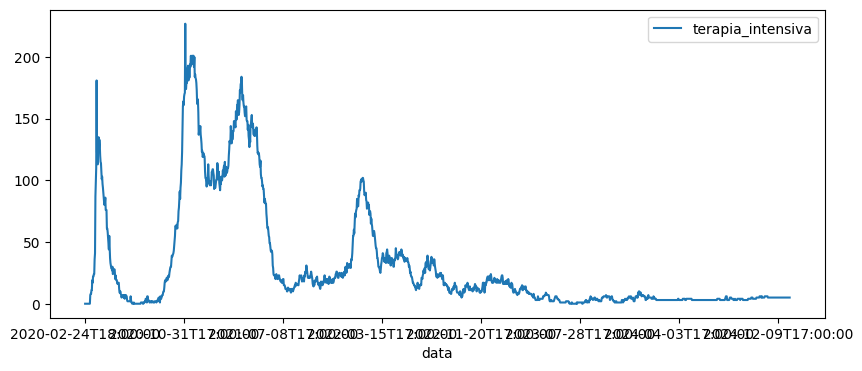

In [22]:
plt.figure()
ax = df_campania.plot(x='data', y='terapia_intensiva', figsize=(10, 4))
plt.show()

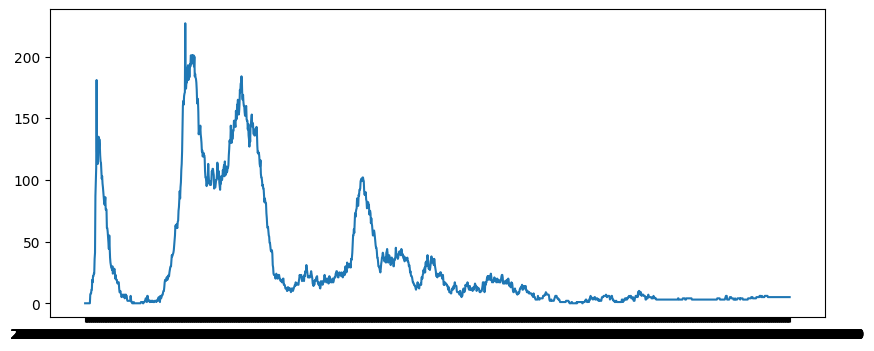

In [23]:
plt.figure(figsize=(10, 4))
ax = plt.plot(df_campania['data'], df_campania['terapia_intensiva'])
plt.show()

Manipolazione delle date

In [24]:
df.data

0        2020-02-24T18:00:00
1        2020-02-24T18:00:00
2        2020-02-24T18:00:00
3        2020-02-24T18:00:00
4        2020-02-24T18:00:00
                ...         
37396    2025-01-08T17:00:00
37397    2025-01-08T17:00:00
37398    2025-01-08T17:00:00
37399    2025-01-08T17:00:00
37400    2025-01-08T17:00:00
Name: data, Length: 37401, dtype: object

In [25]:
df['data_dt'] = pd.to_datetime(df.data)

In [26]:
df[['data', 'data_dt']]

,data,data_dt
0,2020-02-24T18:00:00,2020-02-24 18:00:00
1,2020-02-24T18:00:00,2020-02-24 18:00:00
2,2020-02-24T18:00:00,2020-02-24 18:00:00
3,2020-02-24T18:00:00,2020-02-24 18:00:00
4,2020-02-24T18:00:00,2020-02-24 18:00:00
...,...,...
37396,2025-01-08T17:00:00,2025-01-08 17:00:00
37397,2025-01-08T17:00:00,2025-01-08 17:00:00
37398,2025-01-08T17:00:00,2025-01-08 17:00:00
37399,2025-01-08T17:00:00,2025-01-08 17:00:00


In [27]:
day_1 = df.data_dt.min()

In [28]:
day_1

Timestamp('2020-02-24 18:00:00')

In [29]:
df['giorni'] = (df.data_dt - day_1).dt.days

In [30]:
df[['giorni', 'data_dt']]

,giorni,data_dt
0,0,2020-02-24 18:00:00
1,0,2020-02-24 18:00:00
2,0,2020-02-24 18:00:00
3,0,2020-02-24 18:00:00
4,0,2020-02-24 18:00:00
...,...,...
37396,1779,2025-01-08 17:00:00
37397,1779,2025-01-08 17:00:00
37398,1779,2025-01-08 17:00:00
37399,1779,2025-01-08 17:00:00


In [31]:
df_campania = df.loc[df.denominazione_regione == "Campania"]

In [32]:
df_campania[['giorni', 'data_dt']]

,giorni,data_dt
3,0,2020-02-24 18:00:00
24,1,2020-02-25 18:00:00
45,2,2020-02-26 18:00:00
66,3,2020-02-27 18:00:00
87,4,2020-02-28 18:00:00
...,...,...
37299,1775,2025-01-04 17:00:00
37320,1776,2025-01-05 17:00:00
37341,1777,2025-01-06 17:00:00
37362,1778,2025-01-07 17:00:00


In [33]:
df_regione = df.loc[(df.denominazione_regione=='Piemonte') & (df.giorni > 204)].copy().reset_index(drop=True)

In [34]:
df_regione

,data,stato,codice_regione,denominazione_regione,lat,long,ricoverati_con_sintomi,terapia_intensiva,totale_ospedalizzati,isolamento_domiciliare,...,note_test,note_casi,totale_positivi_test_molecolare,totale_positivi_test_antigenico_rapido,tamponi_test_molecolare,tamponi_test_antigenico_rapido,codice_nuts_1,codice_nuts_2,data_dt,giorni
0,2020-09-17T17:00:00,ITA,1,Piemonte,45.073274,7.680687,136,6,142,2080,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-09-17 17:00:00,205
1,2020-09-18T17:00:00,ITA,1,Piemonte,45.073274,7.680687,140,6,146,2116,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-09-18 17:00:00,206
2,2020-09-19T17:00:00,ITA,1,Piemonte,45.073274,7.680687,140,6,146,2158,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-09-19 17:00:00,207
3,2020-09-20T17:00:00,ITA,1,Piemonte,45.073274,7.680687,142,7,149,2177,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-09-20 17:00:00,208
4,2020-09-21T17:00:00,ITA,1,Piemonte,45.073274,7.680687,143,7,150,2208,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-09-21 17:00:00,209
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1570,2025-01-04T17:00:00,ITA,1,Piemonte,45.073274,7.680687,51,1,52,59849,...,NaN,NaN,520411.0,1300540.0,5158967.0,17730856.0,ITC,ITC1,2025-01-04 17:00:00,1775
1571,2025-01-05T17:00:00,ITA,1,Piemonte,45.073274,7.680687,51,1,52,59853,...,NaN,NaN,520411.0,1300549.0,5158974.0,17731039.0,ITC,ITC1,2025-01-05 17:00:00,1776
1572,2025-01-06T17:00:00,ITA,1,Piemonte,45.073274,7.680687,51,1,52,59849,...,NaN,NaN,520411.0,1300552.0,5158976.0,17731253.0,ITC,ITC1,2025-01-06 17:00:00,1777
1573,2025-01-07T17:00:00,ITA,1,Piemonte,45.073274,7.680687,48,1,49,59852,...,NaN,NaN,520411.0,1300558.0,5158976.0,17731449.0,ITC,ITC1,2025-01-07 17:00:00,1778


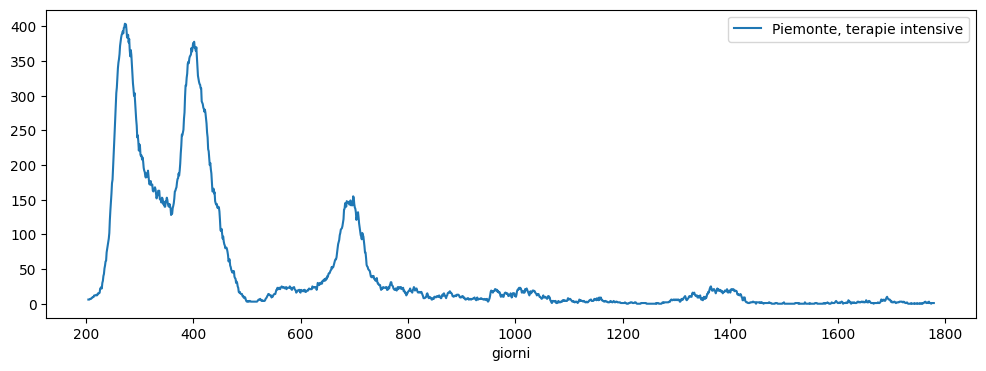

In [37]:
fig, ax = plt.subplots()
df_regione.plot(x='giorni', y='terapia_intensiva', ax=ax, figsize=(12,4), label='Piemonte, terapie intensive')
plt.show()
# In alternativa, è possibile passare direttamente le colonne del DataFramce a matplotlib:
#plt.plot(df_regione['giorni'],df_regione['terapia_intensiva'])

Per calcolare la differenza con ciascuno dei giorni precedenti basta fare lo *shift* della colonna e sottrarla alla colonna stessa:

In [38]:
df_regione['terapia_intensiva_gg'] = df_regione.terapia_intensiva - df_regione.terapia_intensiva.shift(1)

Per fare lo stesso calcolo con un codice tradizionale che usa un loop, il codice diventa decisamente più involuto. <span style="color:blue;">Ogni volta che è possibile, conviene usare le funzioni di pandas perché sono più efficienti e richiedono meno linee di codice.</span>

In [41]:
df_regione[['terapia_intensiva', 'terapia_intensiva_gg']]

,terapia_intensiva,terapia_intensiva_gg
0,6,NaN
1,6,0.0
2,6,0.0
3,7,1.0
4,7,0.0
...,...,...
1570,1,1.0
1571,1,0.0
1572,1,0.0
1573,1,0.0


Per il calcolo della **media mobile**, è possibile usare la funzione [```rolling```](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.rolling.html) che raggruppa gli ultimi valori per poter calcolare semplici indicatori statistici (somma, media, ecc.). Esistono opzioni per dare un peso ai diversi valori per usi molto particolari.

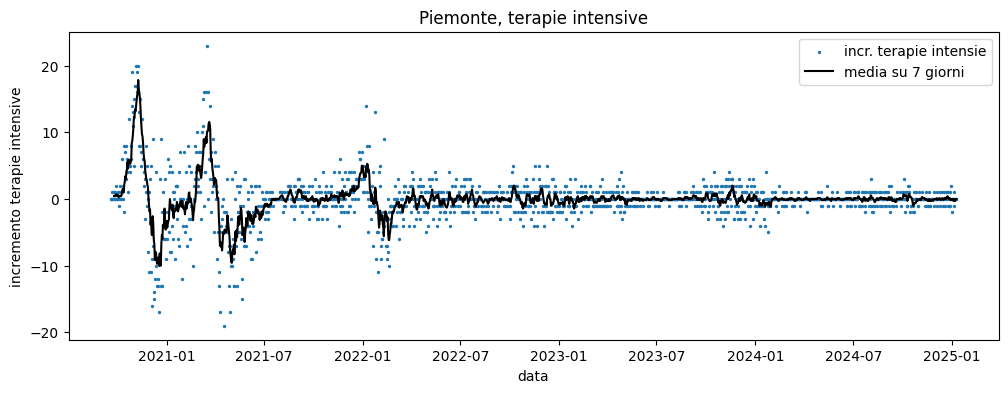

In [43]:
fig, ax = plt.subplots(figsize=(12,4))
ax.scatter(x=df_regione.data_dt, y=df_regione.terapia_intensiva_gg, s=2, label='incr. terapie intensie')
ax.plot(df_regione.data_dt, df_regione.terapia_intensiva_gg.rolling(window=7).mean(), color='black', label='media su 7 giorni')
ax.set_title('Piemonte, terapie intensive')
ax.set_xlabel('data')
ax.set_ylabel('incremento terapie intensive')
ax.legend()

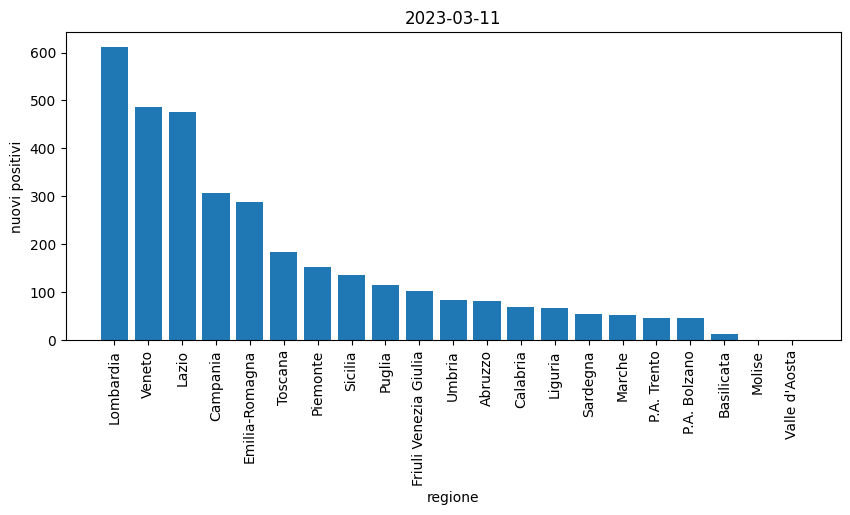

In [45]:
date = '2023-03-11'
df_today = df[df.data==f'{date}T17:00:00'].copy().reset_index(drop=True)
df_today = df_today.sort_values(by=['nuovi_positivi'], ascending=False)
fig, ax = plt.subplots(figsize=(10,4))
ax.bar(df_today.denominazione_regione, df_today.nuovi_positivi)
ax.set_xlabel('regione')
ax.set_ylabel('nuovi positivi')
plt.title(date)
plt.xticks(rotation='vertical')
plt.show()

# Spunti per esercizi

* usando lo stesso dataframe del Dipartimento della Protezione Civile, fare grafici delle seguenti quantità:
    * totale positivi in Campania (o una regione che preferite) in funzione della data
    * positivi giornalieri in Campania in funzione della data
    * media mobile a 7 giorni dei positivi giornalieri in Campania in funzione della data
    * distribuzione del numero di decessi totale per regione ad oggi
    * distribuzione del numero di positivi giornalieri rispetto al numero di tamponi fatti in funzione della data
    * ...

* creare un data frame con la propria agenda telefonica.

*Hint* usare tutorial e guide in rete su come creare un DataFrame da zero. Ad esempio [questo](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.html).

* creare un data frame con i risultati del calendario di serie A e da questo determinare la classifica.

*Hint*: alcuni dati si possono trovare [qui](https://www.kaggle.com/massibelloni/serie-a-19932017) oppure [qui](https://www.football-data.co.uk/italym.php) in formato CSV. Il significato degli acronimi si trova [qui](https://rstudio-pubs-static.s3.amazonaws.com/338127_f85723bf6d9b4637a4c5e1ff8f838432.html).

* Variazione sul tema: creare un data frame con il numero di rigori per stagione di ciascuna squadra e graficare l'andamento negli anni

*Hint*: le statistiche sui rigori ricevuti si trovano su <a href="https://www.transfermarkt.it/serie-a/topErhalteneElfmeter/wettbewerb/IT1/plus/?saison_id=2018">transfermarkt</a>. Ma non sono scaricabili in CSV. <a href="https://www.kaggle.com/emilerichard/penalty-statistics-20192020">qui</a> c'è il file per il 2019-2020.

Altri esempi di dataset si possono trovare nei seguenti repositories:
* <a href="https://datasetsearch.research.google.com/">Google dataset search</a>
* <a href="https://www.kaggle.com/">Kaggle</a>
* <a href="https://archive.ics.uci.edu/ml/index.php">Machine learning repository</a>
* <a href="https://datahub.io/">DataHub</a>
* <a href="https://data.humdata.org/dataset">HDX</a>

<span style="color: gray">Si ringrazia G. Bonifazi per le fonti citate sopra.</span>